# The tengri API: Model, Fitter, Posterior

tengri has three core objects: `Model` (forward model), `Fitter` (inference
engine), `Posterior` (results container). This notebook shows how to create,
configure, inspect, and compose them. You'll also learn the three JAX
patterns that make everything fast: `jit` (compile), `vmap` (batch),
`grad` (differentiate).

In [1]:
import time
import warnings

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

from tengri import (
    Fitter,
    Fixed,
    Gaussian,
    LogNormal,
    LogUniform,
    Model,
    ParamSpec,
    StudentT,
    Uniform,
    load_filter_set,
    load_ssp_data,
)

import sys, os  # noqa: E401, E402
try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    sys.path.insert(0, os.path.join(_nb_dir, "..", ".."))
except NameError:
    _nb_dir = os.getcwd()
    sys.path.insert(0, os.path.join(_nb_dir, ".."))
# Change to project root so data/ paths work
# chdir to project root for data/ access
if os.path.exists("data"):
    pass  # already in project root
elif os.path.exists(os.path.join("..", "data")):
    os.chdir("..")
elif os.path.exists(os.path.join("..", "..", "data")):
    os.chdir(os.path.join("..", ".."))
elif os.path.exists(os.path.join("..", "..", "..", "data")):
    os.chdir(os.path.join("..", "..", ".."))

FIGDIR = os.path.join("tutorials", "figures")
os.makedirs(FIGDIR, exist_ok=True)

from _plot_style import setup_style, COLORS  # noqa: E402

setup_style()

In [2]:
ssp_data = load_ssp_data(
    "data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5"
)
filters = load_filter_set(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"])

## ParamSpec: Defining Your Model

Every fit starts with a ParamSpec. It declares which parameters are free,
what priors they have, and which are fixed. The ParamSpec is the single
source of truth for mock generation, inference, and parameter fixing.

In [3]:
# Build a ParamSpec step by step
spec = ParamSpec(
    # SFH shape (truncated skew-normal, Bellstedt+2020)
    sfh_tsnorm_log_peak_sfr=Uniform(-1.0, 2.5),        # log10(peak SFR)
    sfh_tsnorm_peak_lbt_gyr=Uniform(0.5, 12.0),        # peak lookback time
    sfh_tsnorm_width_gyr=Uniform(0.3, 5.0),             # Gaussian width
    sfh_tsnorm_skew=Uniform(-3.0, 3.0),                 # skewness
    sfh_tsnorm_trunc=Uniform(1.0, 10.0),                # truncation sharpness
    # Metallicity
    met_logzsol=Uniform(-2.0, 0.2),                     # log(Z/Zsun)
    # Dust (Charlot & Fall 2000)
    dust_tau_bc=Uniform(0.0, 2.0),                      # birth cloud optical depth
    dust_tau_diff=Uniform(0.0, 1.5),                    # diffuse ISM optical depth
    dust_slope=Fixed(-0.7),                              # attenuation slope (fixed)
    # Redshift
    redshift=Fixed(0.1),                                 # Fixed → enables precomputation
    # Model configuration
    mean_sfh_type="tsnorm",
)

# Scalar shorthand: dust_slope=-0.7 is identical to Fixed(-0.7)
print(f"Free parameters: {spec.n_free}")
for name in spec.free_params:
    print(f"  {name}")

Free parameters: 8
  dust_tau_bc
  dust_tau_diff
  met_logzsol
  sfh_tsnorm_log_peak_sfr
  sfh_tsnorm_peak_lbt_gyr
  sfh_tsnorm_skew
  sfh_tsnorm_trunc
  sfh_tsnorm_width_gyr


In [4]:
# Inspect the ParamSpec
print(f"\nFree params:  {spec.free_params}")
print(f"Fixed params: {spec.fixed_params}")
print(f"Total free:   {spec.n_free}")
print(f"Stochastic:   {spec.stochastic}")


Free params:  ['dust_tau_bc', 'dust_tau_diff', 'met_logzsol', 'sfh_tsnorm_log_peak_sfr', 'sfh_tsnorm_peak_lbt_gyr', 'sfh_tsnorm_skew', 'sfh_tsnorm_trunc', 'sfh_tsnorm_width_gyr']
Fixed params: ['dust_Rv', 'dust_bump_strength', 'dust_delta', 'dust_f_obscuration', 'dust_slope', 'met_alpha_fe', 'noise_dof', 'noise_frac_cal', 'redshift']
Total free:   8
Stochastic:   False


In [5]:
# Standardization: the key to universal inference
#
# In latent space, every parameter has a standard Gaussian prior N(0,1).
# This is what makes all inference methods work on the same loss function.
# The physics enters through the forward model f(ξ), not through the prior.
#
# Each Distribution has standardize() and unstandardize() methods.
key = jax.random.PRNGKey(0)
params = spec.sample(key)

print("Round-trip test: physical → latent → physical (should match):")
for name in spec.free_params:
    dist = spec.get_distribution(name)
    theta = params[name]
    xi = dist.standardize(theta)
    theta_rt = dist.unstandardize(xi)
    match = abs(float(theta) - float(theta_rt)) < 1e-10
    print(f"  {name:<35s}: {float(theta):.6f} → ξ={float(xi):.4f} → {float(theta_rt):.6f}  {'✓' if match else '✗'}")

Round-trip test: physical → latent → physical (should match):


  dust_tau_bc                        : 1.240230 → ξ=0.4900 → 1.240230  ✓
  dust_tau_diff                      : 1.162709 → ξ=1.2376 → 1.162709  ✓
  met_logzsol                        : 0.008935 → ξ=2.3527 → 0.008935  ✓
  sfh_tsnorm_log_peak_sfr            : 2.451230 → ξ=4.2594 → 2.451230  ✓
  sfh_tsnorm_peak_lbt_gyr            : 8.055667 → ξ=0.6500 → 8.055667  ✓
  sfh_tsnorm_skew                    : 0.629661 → ξ=0.4261 → 0.629661  ✓
  sfh_tsnorm_trunc                   : 4.578517 → ξ=-0.4154 → 4.578517  ✓
  sfh_tsnorm_width_gyr               : 3.222884 → ξ=0.4976 → 3.222884  ✓


W0321 12:46:51.512259 14615708 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


In [6]:
# Sample from the prior
samples = jax.vmap(spec.sample)(jax.random.split(key, 5))
print("\n5 prior samples:")
print(f"  {'Parameter':<35s} {'S1':>8s} {'S2':>8s} {'S3':>8s} {'S4':>8s} {'S5':>8s}")
for name in spec.free_params:
    vals = [f"{float(samples[name][i]):.3f}" for i in range(5)]
    print(f"  {name:<35s} " + " ".join(f"{v:>8s}" for v in vals))


5 prior samples:
  Parameter                                 S1       S2       S3       S4       S5
  dust_tau_bc                            1.682    0.493    1.322    0.343    0.193
  dust_tau_diff                          0.240    1.356    1.489    0.354    0.844
  met_logzsol                           -0.602   -1.244   -0.889   -0.149   -1.801
  sfh_tsnorm_log_peak_sfr               -0.087    2.329    0.259    0.142    1.017
  sfh_tsnorm_peak_lbt_gyr                3.704    2.068   10.079    1.117   10.004
  sfh_tsnorm_skew                       -0.288   -0.198    0.390    2.689   -0.179
  sfh_tsnorm_trunc                       4.436    5.402    3.588    6.040    2.263
  sfh_tsnorm_width_gyr                   1.089    3.835    3.961    0.339    4.339


In [7]:
# Available distributions
print("\nBuilt-in distributions:")
print(f"  {'Distribution':<15s} {'Usage'}")
print("  " + "-" * 60)
print(f"  {'Uniform':<15s} Most parameters — flat between lo and hi")
print(f"  {'Gaussian':<15s} Informative prior (mean, std)")
print(f"  {'LogUniform':<15s} Scale parameters (e.g., timescales)")
print(f"  {'LogNormal':<15s} Positive quantities with log-space spread")
print(f"  {'StudentT':<15s} Heavy-tailed prior (robust to outliers)")
print(f"  {'Fixed':<15s} Held constant during inference")


Built-in distributions:
  Distribution    Usage
  ------------------------------------------------------------
  Uniform         Most parameters — flat between lo and hi
  Gaussian        Informative prior (mean, std)
  LogUniform      Scale parameters (e.g., timescales)
  LogNormal       Positive quantities with log-space spread
  StudentT        Heavy-tailed prior (robust to outliers)
  Fixed           Held constant during inference


## Model: The Differentiable Forward Model

The Model wraps the full SPS pipeline — from parameters through SFH, CSP
integration, dust, and filter convolution — into a single differentiable
function.

In [8]:
model = Model(spec, ssp_data, filters=filters)
print(f"Model created: {spec.n_free} free parameters")

Model created: 8 free parameters


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_99786/2660781994.py:1: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model = Model(spec, ssp_data, filters=filters)


In [9]:
# Predict a spectrum
WAVE_OBS = jnp.linspace(3800.0, 9200.0, 200)
model.precompute_spectroscopy(WAVE_OBS)

params = spec.sample(jax.random.PRNGKey(42))
spectrum = model.predict_spectrum(params)
print(f"Spectrum shape: {spectrum.shape}")

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_99786/938574274.py:3: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model.precompute_spectroscopy(WAVE_OBS)


Spectrum shape: (200,)


In [10]:
# Predict photometry
phot = model.predict_photometry(params)
print(f"Photometry ({len(filters)} bands): {np.array(phot)}")

Photometry (3 bands): [2.49891209e-29 1.78838839e-28 4.86562867e-28 7.71721255e-28
 1.21057137e-27]


In [11]:
# Precomputation speedup
# Spectroscopy precomputation is already active.
# Photometry precomputation activates automatically when redshift is fixed.
# Let's measure the speedup:
jit_spec = jax.jit(model.predict_spectrum)
_ = jit_spec(params)  # compile

n = 1000
t0 = time.perf_counter()
for _ in range(n):
    r = jit_spec(params)
    r.block_until_ready()
t_precomp = (time.perf_counter() - t0) / n * 1e6
print(f"Predict spectrum (precomputed): {t_precomp:.0f} µs")

Predict spectrum (precomputed): 98 µs


In [12]:
# JIT compilation
jit_phot = jax.jit(model.predict_photometry)
_ = jit_phot(params)  # compile

t0 = time.perf_counter()
for _ in range(n):
    r = jit_phot(params)
    r.block_until_ready()
t_phot = (time.perf_counter() - t0) / n * 1e6
print(f"Predict photometry (JIT): {t_phot:.0f} µs")

Predict photometry (JIT): 35 µs


In [13]:
# vmap: Batch prediction
batch_predict = jax.jit(jax.vmap(model.predict_photometry))
batch_times = {}

for n_batch in [10, 100, 1000]:
    keys = jax.random.split(jax.random.PRNGKey(0), n_batch)
    batch_params = jax.vmap(spec.sample)(keys)
    _ = batch_predict(batch_params)  # compile

    t0 = time.perf_counter()
    for _ in range(50):
        r = batch_predict(batch_params)
        r.block_until_ready()
    t = (time.perf_counter() - t0) / 50 * 1e3
    batch_times[n_batch] = t
    print(f"  vmap({n_batch:>4d} galaxies): {t:.1f} ms  ({t/n_batch*1e3:.1f} µs/galaxy)")

  vmap(  10 galaxies): 0.1 ms  (11.0 µs/galaxy)


  vmap( 100 galaxies): 0.4 ms  (4.2 µs/galaxy)


  vmap(1000 galaxies): 1.8 ms  (1.8 µs/galaxy)


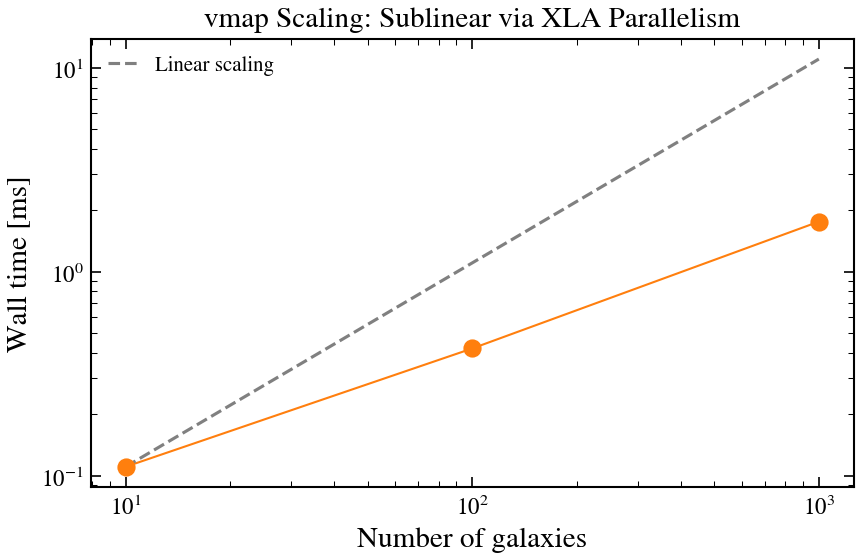

In [14]:
# --- FIGURE 1: vmap scaling ---
ns = np.array(list(batch_times.keys()))
ts = np.array(list(batch_times.values()))

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(ns, ts, s=60, color=COLORS["geovi"], zorder=3)
ax.plot(ns, ts, color=COLORS["geovi"], lw=1)

# Linear reference
linear = ts[0] / ns[0] * ns
ax.plot(ns, linear, ls="--", color="grey", label="Linear scaling")

ax.set_xlabel("Number of galaxies")
ax.set_ylabel("Wall time [ms]")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()
ax.set_title("vmap Scaling: Sublinear via XLA Parallelism")
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig01_vmap_scaling.png"), dpi=150, bbox_inches="tight")
plt.show()

In [15]:
# Gradients for free
grad_fn = jax.jit(jax.grad(lambda p: jnp.sum(model.predict_spectrum(p))))
_ = grad_fn(params)

t0 = time.perf_counter()
for _ in range(n):
    g = grad_fn(params)
    jax.tree.map(lambda x: x.block_until_ready(), g)
t_grad = (time.perf_counter() - t0) / n * 1e6
print(f"Gradient:  {t_grad:.0f} µs  ({t_grad/t_precomp:.1f}× forward pass)")

# Full Jacobian (returns a dict of arrays: one per parameter)
J = jax.jacobian(model.predict_spectrum)(params)
first_key = list(J.keys())[0]
print(f"Jacobian: {len(J)} parameter entries, first shape: {J[first_key].shape}")
print("Gradients cost ~1.5× the forward pass. This is what makes geoVI and RT possible.")

Gradient:  192 µs  (2.0× forward pass)


Jacobian: 17 parameter entries, first shape: (200,)
Gradients cost ~1.5× the forward pass. This is what makes geoVI and RT possible.


In [16]:
# SFH and derived quantities
sfh = model.predict_sfh(params)
print(f"\nSFH keys: {list(sfh.keys())}")
print(f"  t_gyr shape: {sfh['t_gyr'].shape}")
print(f"  sfr_mean shape: {sfh['sfr_mean'].shape}")
print(f"  sfr_full shape: {sfh['sfr_full'].shape}")


SFH keys: ['t_gyr', 'sfr_mean', 'sfr_full']
  t_gyr shape: (1000,)
  sfr_mean shape: (1000,)
  sfr_full shape: (1000,)


## Fitter: Inference Engine

The Fitter connects a Model to observed data and runs inference. It builds
the loss function, handles standardization, and dispatches to any of the
5+ inference backends.

In [17]:
# Generate mock data
mock = model.mock_spectrum(params, WAVE_OBS, snr=30.0, key=jax.random.PRNGKey(99))
fitter = Fitter(model, mock.flux_obs, mock.noise, data_type="spectroscopy")
print(f"Fitter: {len(mock.flux_obs)} data points, {spec.n_free} parameters")

Fitter: 200 data points, 8 parameters


In [18]:
# The loss function (information Hamiltonian)
# H(ξ) = ½χ² + ½ξᵀξ — every inference method minimizes or samples from this.
# The Fitter builds this internally. All we need to do is call .run():
print("H(ξ) = ½χ² + ½ξᵀξ — every method minimizes or samples from this.")
print(f"  ξ dimension: {spec.n_free}")
print(f"  Data dimension: {len(mock.flux_obs)}")

H(ξ) = ½χ² + ½ξᵀξ — every method minimizes or samples from this.
  ξ dimension: 8
  Data dimension: 200


In [19]:
# MAP — point estimate
result_map = fitter.run("map", n_steps=500, verbose=False)
print(f"MAP: {result_map.wall_time_s:.1f}s, final loss = {float(result_map.loss_history[-1]):.1f}")

MAP: 0.3s, final loss = 1294.9


In [20]:
# native_geovi — approximate posterior
result_geovi = fitter.run(
    "native_geovi", n_iterations=15, n_samples=6, n_seeds=3,
    n_posterior_samples=2000, verbose=False,
)
print(f"native_geovi: {result_geovi.wall_time_s:.1f}s, {len(list(result_geovi.samples.values())[0])} samples")

assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/nifty8/re/model.py:164: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)


W0321 12:46:58.246929 14615614 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0321 12:48:06.730853 14615614 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


native_geovi: 86.3s, 2000 samples


In [21]:
# Ray Tracing — exact MCMC
result_rt = fitter.run(
    "raytrace", init_from=result_map,
    n_burnin=100, n_steps=500, verbose=False,
)
acc = result_rt.diagnostics.get("acceptance_rate", float("nan"))
print(f"Ray Tracing: {result_rt.wall_time_s:.1f}s, acceptance = {acc:.1%}")

Ray Tracing: 0.4s, acceptance = nan%


In [22]:
# Switching methods is trivial
print("\nSwitching methods is one line:")
print('  fitter.run("native_geovi")  # approximate, fast')
print('  fitter.run("raytrace")      # exact, any D')
print('  fitter.run("nuts")          # exact, D < 20')
print("\nSame model, same data, same loss — different exploration strategy.")


Switching methods is one line:
  fitter.run("native_geovi")  # approximate, fast
  fitter.run("raytrace")      # exact, any D
  fitter.run("nuts")          # exact, D < 20

Same model, same data, same loss — different exploration strategy.


## Posterior: Working with Results

The result object stores samples, diagnostics, and timing. It provides
methods for summary statistics, derived quantities, and plotting.

In [23]:
# Inspect the Posterior
result = result_geovi
print(f"Method:    {result.method}")
print(f"Wall time: {result.wall_time_s:.1f}s")
print(f"Samples:   {len(list(result.samples.values())[0])} draws")

# Summary: median ± 68% CI for each parameter
summary = result.summary()
print(f"\n{'Parameter':<35s} {'Median':>10s} {'68% CI'}")
for name, info in summary.items():
    if "median" in info:
        med = info["median"]
        lo, hi = info.get("lo_68", float("nan")), info.get("hi_68", float("nan"))
        print(f"  {name:<33s} {med:>10.4f}  [{lo:.4f}, {hi:.4f}]")

Method:    EVI (JIT)
Wall time: 86.3s
Samples:   2000 draws

Parameter                               Median 68% CI
  dust_tau_bc                           1.1267  [0.6165, 1.5410]
  dust_tau_diff                         0.9106  [0.8707, 0.9482]
  met_logzsol                          -0.0016  [-0.0618, 0.0426]
  sfh_tsnorm_log_peak_sfr               1.1186  [1.0274, 1.2621]
  sfh_tsnorm_peak_lbt_gyr              10.5887  [9.1182, 11.3933]
  sfh_tsnorm_skew                      -0.1957  [-1.0589, 0.2018]
  sfh_tsnorm_trunc                      6.2019  [4.0609, 8.0515]
  sfh_tsnorm_width_gyr                  2.0482  [1.2248, 3.1943]
  dust_Rv                               3.1000  [3.1000, 3.1000]
  dust_bump_strength                    0.0000  [0.0000, 0.0000]
  dust_delta                            0.0000  [0.0000, 0.0000]
  dust_f_obscuration                    0.0000  [0.0000, 0.0000]
  dust_slope                           -0.7000  [-0.7000, -0.7000]
  met_alpha_fe                     

In [24]:
# summary_table() gives a nicely formatted overview
print(result.summary_table())

Posterior  method: EVI (JIT)  samples: 2000  wall_time: 86.3s
──────────────────────────────────────────────────────────────────
  Parameter                       Median       16%       84%     ESS
  ────────────────────────────────────────────────────────────────
  dust_Rv                         3.1000    3.1000    3.1000       —
  dust_bump_strength              0.0000    0.0000    0.0000       —
  dust_delta                      0.0000    0.0000    0.0000       —
  dust_f_obscuration              0.0000    0.0000    0.0000       —
  dust_slope                     -0.7000   -0.7000   -0.7000       —
  dust_tau_bc                     1.1267    0.6165    1.5410       —
  dust_tau_diff                   0.9106    0.8707    0.9482       —
  met_alpha_fe                    0.0000    0.0000    0.0000       —
  met_logzsol                    -0.0016   -0.0618    0.0426       —
  noise_dof                       0.0000    0.0000    0.0000       —
  noise_frac_cal                  0.0000    0

In [25]:
# SFH from posterior
# We can predict the SFH for each posterior sample
n_sfh_draws = 50
sfh_samples = []
for i in range(n_sfh_draws):
    idx = i % len(result.samples[spec.free_params[0]])
    draw = {k: v[idx] for k, v in result.samples.items()}
    sfh_i = model.predict_sfh(draw)
    sfh_samples.append(np.array(sfh_i["sfr_full" if "sfr_full" in sfh_i else "sfr_mean"]))

sfh_arr = np.array(sfh_samples)
t_gyr = np.array(model.predict_sfh(params)["t_gyr"])
print(f"SFH posterior: {sfh_arr.shape[0]} draws × {sfh_arr.shape[1]} time points")

SFH posterior: 50 draws × 1000 time points


In [26]:
# Convergence diagnostics
if hasattr(result, "effective_sample_size"):
    try:
        ess = result.effective_sample_size()
        print("\nEffective Sample Size:")
        for name, val in ess.items():
            print(f"  {name:<35s}: {float(val):.0f}")
    except Exception:
        print("(ESS not available for this method)")


Effective Sample Size:
  dust_tau_bc                        : 1867
  dust_tau_diff                      : 2000
  met_logzsol                        : 1893
  sfh_tsnorm_log_peak_sfr            : 1611
  sfh_tsnorm_peak_lbt_gyr            : 2000
  sfh_tsnorm_skew                    : 2000
  sfh_tsnorm_trunc                   : 2000
  sfh_tsnorm_width_gyr               : 1577
  dust_Rv                            : 2000
  dust_bump_strength                 : 2000
  dust_delta                         : 2000
  dust_f_obscuration                 : 2000
  dust_slope                         : 2000
  met_alpha_fe                       : 2000
  noise_dof                          : 2000
  noise_frac_cal                     : 2000
  redshift                           : 2000


## The JAX Mental Model

tengri is built on JAX. Three things to know:

1. **jit** — compiles functions. Slow first call (tracing), fast after.
2. **vmap** — vectorizes over a batch dimension. Use it for catalogs.
3. **grad** — automatic differentiation. This is why native_geovi works:
   gradients flow through the entire SPS pipeline for free.

The forward model runs in ~40 µs JIT'd. Gradients cost ~1.5× that. Batch
processing is sublinear via XLA parallelism.

## Summary

You now know the three core objects and three JAX patterns:

| Object | Purpose | Key methods |
|--------|---------|-------------|
| `ParamSpec` | Define parameters and priors | `.sample()`, `.standardize()` |
| `Model` | Forward model | `.predict_spectrum()`, `.predict_sfh()`, `.mock()` |
| `Fitter` | Inference engine | `.run("native_geovi")`, `.run("raytrace")` |
| `Posterior` | Results container | `.samples`, `.summary()`, `.diagnostics` |

Next: **tutorials/03** explains the IFT/PSD/GP machinery that generates
bursty SFHs.